<a href="https://colab.research.google.com/github/VenkataViswas/A_MTech-Sem2-Lab-Programs/blob/main/BA/Customer_churn_perdiction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## About Dataset
This dataset is being shared for the first time for public research after extensive research performed.

This dataset is perfect for practicing prescriptive analysis such as predictive prescription or predictive decision making. The reason is that the dataset has the attribute of customer value which allows for creating False Positive (FP) and False Negative(FN) costs in case of misclassification. In standard classification tasks, it is assumed that FPs and FNs are the same, which is not the case for many cases. Furthermore, even if it is recognized that FPs and FNs are indeed different, their different balances per each data object are not understood or taken into consideration. This dataset gives you the opportunity to create a model that recognizes these complexities. For further information about the balance of FPs and FNs see the first mentioned publication. Also, you can find more information about each attribute on one of the publications.

## downloading the dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("royjafari/customer-churn")

print("Path to dataset files:", path)

100%|██████████| 63.1k/63.1k [00:00<00:00, 10.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/royjafari/customer-churn/versions/1


## loding the required modules

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
import pandas as pd

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Dataset loaded successfully")


Dataset loaded successfully


In [ ]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'FN', 'FP', 'Churn'],
      dtype='object')

In [ ]:
df.drop(["FN","FP"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [ ]:
df.isna().sum()

,0
Call Failure,0
Complains,0
Subscription Length,0
Charge Amount,0
Seconds of Use,0
Frequency of use,0
Frequency of SMS,0
Distinct Called Numbers,0
Age Group,0
Tariff Plan,0


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
def count_class_labels(target_series):
    class_counts = target_series.value_counts()
    num_zeros = class_counts.get(0, 0)  # Get count for 0, default to 0 if not present
    num_ones = class_counts.get(1, 0)   # Get count for 1, default to 0 if not present

    print(f"Number of 0s: {num_zeros}")
    print(f"Number of 1s: {num_ones}")

# Call the function with the target variable 'y'
print("Class label counts in the entire dataset:")
count_class_labels(y)


Class label counts in the entire dataset:
Number of 0s: 2655
Number of 1s: 495


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data successfully split into training and testing sets.
X_train shape: (2520, 13)
X_test shape: (630, 13)
y_train shape: (2520,)
y_test shape: (630,)


## Classification model

In [ ]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully using StandardScaler.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully using StandardScaler.
X_train_scaled shape: (2520, 13)
X_test_scaled shape: (630, 13)


## Define and Compile ANN Model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Get the number of features from the scaled training data
input_dim = X_train_scaled.shape[1]

# Initialize the ANN model
ann_model = Sequential()

# Add the input layer and the first hidden layer
ann_model.add(Dense(units=64, activation='relu', input_shape=(input_dim,)))

# Add a second hidden layer
ann_model.add(Dense(units=32, activation='relu'))

# Add the output layer
ann_model.add(Dense(units=1, activation='sigmoid'))

# Compile the ANN model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("ANN model defined and compiled successfully.")
ann_model.summary()

ANN model defined and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = ann_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=1)

print("ANN model trained successfully.")

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6848 - loss: 0.5880 - val_accuracy: 0.8778 - val_loss: 0.2962
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9013 - loss: 0.2308 - val_accuracy: 0.8778 - val_loss: 0.2751
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9047 - loss: 0.2283 - val_accuracy: 0.8937 - val_loss: 0.2700
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9267 - loss: 0.1873 - val_accuracy: 0.8857 - val_loss: 0.2622
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9168 - loss: 0.1932 - val_accuracy: 0.8905 - val_loss: 0.2574
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9289 - loss: 0.1787 - val_accuracy: 0.8968 - val_loss: 0.2492
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9309 - loss: 0.1762 - val_accuracy: 0.8984 - val_loss: 0.2432
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9268 - loss: 0.1717 - val_accuracy: 0.8889 - val_loss:

In [ ]:
y_pred_proba_ann = ann_model.predict(X_test_scaled)
y_pred_ann = (y_pred_proba_ann > 0.5).astype(int)

print("Predictions generated for ANN model.")
print(f"First 10 predicted probabilities: {y_pred_proba_ann[:10].flatten()}")
print(f"First 10 predicted class labels: {y_pred_ann[:10].flatten()}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Predictions generated for ANN model.
First 10 predicted probabilities: [2.0168759e-15 1.2818508e-25 7.2211986e-03 2.1171877e-13 8.9538999e-22
 1.9362686e-12 2.5909852e-11 1.0611876e-08 1.3110494e-12 8.4599264e-02]
First 10 predicted class labels: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, auc, precision_recall_curve

print("\n--- ANN Model Evaluation ---\n")

# 1. Accuracy Score
accuracy_ann = accuracy_score(y_test, y_pred_ann)
print(f"Accuracy (ANN): {accuracy_ann:.4f}")

# 2. Precision Score
precision_ann = precision_score(y_test, y_pred_ann)
print(f"Precision (ANN): {precision_ann:.4f}")

# 3. Recall Score
recall_ann = recall_score(y_test, y_pred_ann)
print(f"Recall (ANN): {recall_ann:.4f}")

# 4. F1 Score
f1_ann = f1_score(y_test, y_pred_ann)
print(f"F1-Score (ANN): {f1_ann:.4f}")

# 5. ROC AUC Score
roc_auc_ann = roc_auc_score(y_test, y_pred_proba_ann)
print(f"ROC AUC Score (ANN): {roc_auc_ann:.4f}")

# 6. PR AUC Score
precision_vals_ann, recall_vals_ann, _ = precision_recall_curve(y_test, y_pred_proba_ann)
pr_auc_ann = auc(recall_vals_ann, precision_vals_ann)
print(f"PR AUC Score (ANN): {pr_auc_ann:.4f}")



--- ANN Model Evaluation ---

Accuracy (ANN): 0.9413
Precision (ANN): 0.8763
Recall (ANN): 0.7727
F1-Score (ANN): 0.8213
ROC AUC Score (ANN): 0.9776
PR AUC Score (ANN): 0.9226


Custom Confusion Matrix:
[[np.int64(85), np.int64(12)], [np.int64(12), np.int64(25)]]


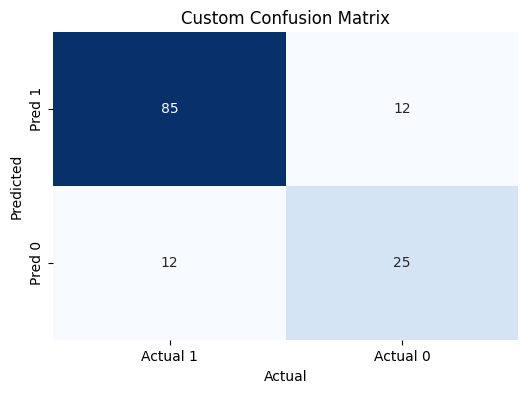

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Original confusion matrix
cm = confusion_matrix(y_test, y_pred_ann)

# Extract values
TN, FP, FN, TP = cm.ravel()

# Rearranged matrix as requested
cm_custom = [[TP, FP],
             [FP, FN]]

print("Custom Confusion Matrix:")
print(cm_custom)

plt.figure(figsize=(6,4))

sns.heatmap(cm_custom,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=['Actual 1', 'Actual 0'],
            yticklabels=['Pred 1', 'Pred 0'])

plt.title("Custom Confusion Matrix")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

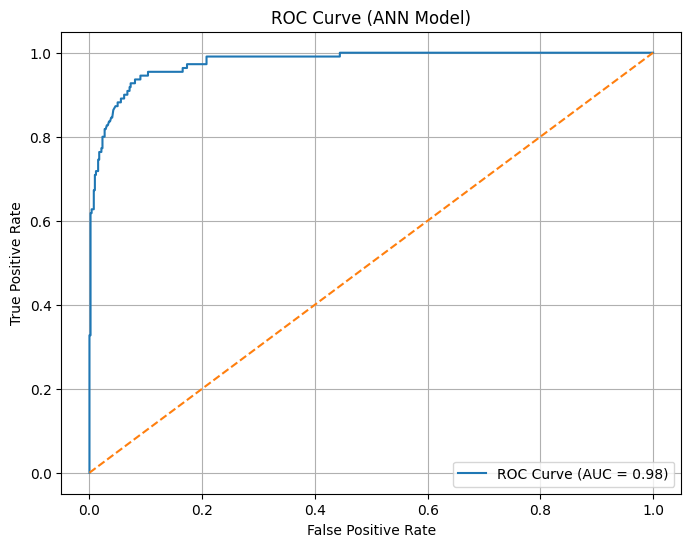

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve values
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_pred_proba_ann)

plt.figure(figsize=(8,6))

plt.plot(fpr_ann, tpr_ann, label=f'ROC Curve (AUC = {roc_auc_ann:.2f})')
plt.plot([0,1], [0,1], linestyle='--')   # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ANN Model)")
plt.legend()
plt.grid(True)

plt.show()


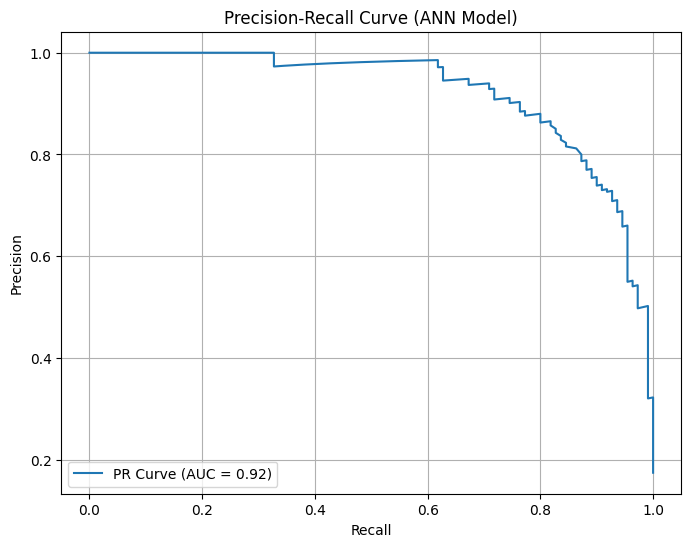

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(recall_vals_ann, precision_vals_ann, label=f'PR Curve (AUC = {pr_auc_ann:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (ANN Model)")
plt.legend(loc="lower left")
plt.grid(True)

plt.show()